# 04 — Panel Regression Analysis

## The drivers of economic growth in Europe: evidence from productivity and investment

This notebook estimates how GDP growth is associated with productivity growth and investment in a balanced panel of **41 European countries from 2000 to 2018**.

The analysis moves from pooled OLS to country fixed effects and then to country-and-year fixed effects. The two-way model is preferred because it controls for persistent differences between countries and common European shocks. Country-clustered standard errors allow each country's regression errors to remain related over time.

**Interpretation boundary:** the results are conditional associations, not causal effects. Fixed effects cannot fully remove reverse causality, measurement error, or omitted factors that change over time.

Education expenditure is not included in the main model because its incomplete, changing coverage would reduce comparability. It remains a supplementary descriptive variable in Notebook 03.

## Reproducibility note

This notebook requires `linearmodels` in addition to the packages used earlier. If the import fails in VS Code, run `%pip install linearmodels` once in a separate cell, restart the kernel, and then run the notebook from the beginning.

In [140]:
# Required libraries
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm

from linearmodels.panel import PooledOLS, PanelOLS, compare
from statsmodels.stats.outliers_influence import variance_inflation_factor

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")
sns.set_theme(style="whitegrid", context="notebook")

## 1. Data import and panel preparation

The balanced core sample is used for the main regression analysis. It contains annual observations for GDP growth, investment, and productivity growth.

The dataset is indexed by country and year, which allows the estimation of panel models with country and time effects.

In [ ]:
# Locate the project folder and import the balanced core sample.
project_dir = Path.cwd()
if project_dir.name == "notebooks":
    project_dir = project_dir.parent

core_file = project_dir / "data" / "processed" / "europe_panel_core_cleaned.csv"
if not core_file.exists():
    raise FileNotFoundError(
        "Run 02_data_cleaning.ipynb first. "
        f"Expected file: {core_file}"
    )

core = pd.read_csv(core_file)

print("Dimensions:", core.shape)
print("Countries:", core["Country Code"].nunique())
print("Period:", core["Year"].min(), "-", core["Year"].max())
display(core.head())

In [142]:
dependent_variable = "GDP Growth"

main_explanatory_variables = [
    "Productivity Growth",
    "Investment"
]

required_columns = [
    "Country Code",
    "Country Name",
    "Year",
    dependent_variable,
    *main_explanatory_variables
]

print(
    "Missing required columns:",
    [
        column
        for column in required_columns
        if column not in core.columns
    ]
)

print(
    "Duplicate country-years:",
    core.duplicated(
        subset=["Country Code", "Year"]
    ).sum()
)

print(
    "Missing regression values:",
    core[
        [
            dependent_variable,
            *main_explanatory_variables
        ]
    ].isna().sum().sum()
)

print(
    "Infinite regression values:",
    np.isinf(
        core[
            [
                dependent_variable,
                *main_explanatory_variables
            ]
        ].to_numpy()
    ).sum()
)

Missing required columns: []
Duplicate country-years: 0
Missing regression values: 0
Infinite regression values: 0


In [143]:
# Arrange and index the panel data
panel = (
    core
    .sort_values(["Country Code", "Year"])
    .set_index(["Country Code", "Year"])
)

print("Panel index names:", panel.index.names)
print("Panel dimensions:", panel.shape)
print("Index is unique:", panel.index.is_unique)

display(panel.head())

Panel index names: ['Country Code', 'Year']
Panel dimensions: (779, 5)
Index is unique: True


Country Name  GDP Growth  Investment  Productivity Growth  \
Country Code Year                                                             
ALB          2000      Albania      7.4629     34.0401               6.6400   
             2001      Albania      8.8637     38.2280               8.2900   
             2002      Albania      4.6284     38.5753               4.5900   
             2003      Albania      5.3333     36.7221               4.8400   
             2004      Albania      5.2663     36.3319               4.9400   

                   Potential_Outlier  
Country Code Year                     
ALB          2000              False  
             2001               True  
             2002               True  
             2003               True  
             2004               True

In [144]:
panel_balance = (
    core
    .groupby("Country Code")["Year"]
    .agg(["min", "max", "count", "nunique"])
)

display(panel_balance.head())

print(
    "Minimum observations per country:",
    panel_balance["count"].min()
)

print(
    "Maximum observations per country:",
    panel_balance["count"].max()
)

print(
    "Balanced panel:",
    panel_balance["count"].nunique() == 1
)

,min,max,count,nunique
Country Code,,,,
ALB,2000,2018,19,19
AUT,2000,2018,19,19
BEL,2000,2018,19,19
BGR,2000,2018,19,19
BIH,2000,2018,19,19


Minimum observations per country: 19
Maximum observations per country: 19
Balanced panel: True


## 2. Main regression specifications

The baseline relationship is represented by:

\[
GDPGrowth_{it}
=
\beta_0
+
\beta_1 ProductivityGrowth_{it}
+
\beta_2 Investment_{it}
+
u_{it}
\]

Three main estimators are considered:

1. **Pooled OLS**, which treats all country-year observations as a single pooled sample.
2. **Country fixed effects**, which control for time-invariant differences between countries.
3. **Two-way fixed effects**, which additionally control for common shocks affecting all countries in a given year.

The coefficients represent contemporaneous associations. They should not automatically be interpreted as causal effects.

In [145]:
# Dependent variable
y = panel[dependent_variable]

# Explanatory variables without a constant
X = panel[main_explanatory_variables]

# Pooled OLS requires an explicit constant
X_pooled = sm.add_constant(
    X,
    has_constant="add"
)

print("Dependent variable dimensions:", y.shape)
print("Explanatory variables dimensions:", X.shape)

display(X_pooled.head())

Dependent variable dimensions: (779,)
Explanatory variables dimensions: (779, 2)


const  Productivity Growth  Investment
Country Code Year                                        
ALB          2000 1.0000               6.6400     34.0401
             2001 1.0000               8.2900     38.2280
             2002 1.0000               4.5900     38.5753
             2003 1.0000               4.8400     36.7221
             2004 1.0000               4.9400     36.3319

### Bivariate pooled models

These first two models examine each driver separately. They are useful descriptive benchmarks, but they do not control for the other driver, country characteristics, or common year shocks.

In [146]:
# Pooled model containing productivity growth only
X_productivity = sm.add_constant(
    panel[["Productivity Growth"]],
    has_constant="add"
)

pooled_productivity_model = PooledOLS(
    dependent=y,
    exog=X_productivity
)

pooled_productivity_results = (
    pooled_productivity_model.fit(
        cov_type="clustered",
        cluster_entity=True
    )
)

print(pooled_productivity_results.summary)

                          PooledOLS Estimation Summary                          
Dep. Variable:             GDP Growth   R-squared:                        0.4920
Estimator:                  PooledOLS   R-squared (Between):              0.5703
No. Observations:                 779   R-squared (Within):               0.4812
Date:                Sun, Aug 09 2026   R-squared (Overall):              0.4920
Time:                        10:03:26   Log-likelihood                   -1857.7
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      752.49
Entities:                          41   P-value                           0.0000
Avg Obs:                       19.000   Distribution:                   F(1,777)
Min Obs:                       19.000                                           
Max Obs:                       19.000   F-statistic (robust):             135.01
                            

In [147]:
# Pooled model containing investment only
X_investment = sm.add_constant(
    panel[["Investment"]],
    has_constant="add"
)

pooled_investment_model = PooledOLS(
    dependent=y,
    exog=X_investment
)

pooled_investment_results = (
    pooled_investment_model.fit(
        cov_type="clustered",
        cluster_entity=True
    )
)

print(pooled_investment_results.summary)

                          PooledOLS Estimation Summary                          
Dep. Variable:             GDP Growth   R-squared:                        0.1536
Estimator:                  PooledOLS   R-squared (Between):              0.2280
No. Observations:                 779   R-squared (Within):               0.1434
Date:                Sun, Aug 09 2026   R-squared (Overall):              0.1536
Time:                        10:03:26   Log-likelihood                   -2056.5
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      141.05
Entities:                          41   P-value                           0.0000
Avg Obs:                       19.000   Distribution:                   F(1,777)
Min Obs:                       19.000                                           
Max Obs:                       19.000   F-statistic (robust):             81.140
                            

### Pooled OLS model

Pooled OLS uses both cross-country and within-country variation but does not control for unobserved country characteristics or common annual shocks.

Country-clustered standard errors allow regression errors to be correlated over time within each country.

In [148]:
pooled_model = PooledOLS(
    dependent=y,
    exog=X_pooled
)

pooled_results = pooled_model.fit(
    cov_type="clustered",
    cluster_entity=True
)

print(pooled_results.summary)

                          PooledOLS Estimation Summary                          
Dep. Variable:             GDP Growth   R-squared:                        0.5370
Estimator:                  PooledOLS   R-squared (Between):              0.4925
No. Observations:                 779   R-squared (Within):               0.5431
Date:                Sun, Aug 09 2026   R-squared (Overall):              0.5370
Time:                        10:03:26   Log-likelihood                   -1821.5
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      450.01
Entities:                          41   P-value                           0.0000
Avg Obs:                       19.000   Distribution:                   F(2,776)
Min Obs:                       19.000                                           
Max Obs:                       19.000   F-statistic (robust):             79.654
                            

In [149]:
pooled_table = pd.DataFrame({
    "Coefficient": pooled_results.params,
    "Standard Error": pooled_results.std_errors,
    "t-statistic": pooled_results.tstats,
    "p-value": pooled_results.pvalues,
    "CI Lower": pooled_results.conf_int().iloc[:, 0],
    "CI Upper": pooled_results.conf_int().iloc[:, 1]
})

display(pooled_table.round(4))

,Coefficient,Standard Error,t-statistic,p-value,CI Lower,CI Upper
const,-2.4883,0.7091,-3.5089,0.0005,-3.8804,-1.0962
Productivity Growth,0.7204,0.0621,11.6041,0.0000,0.5986,0.8423
Investment,0.1607,0.0280,5.7352,0.0000,0.1057,0.2157


## 3. Country fixed effects

Country fixed effects control for characteristics that differ across countries but remain approximately constant over time, including geography, long-established institutions, historical structures, and persistent cultural or economic differences.

The coefficients are therefore identified using changes within each country over time.

In [150]:
country_fe_model = PanelOLS(
    dependent=y,
    exog=X,
    entity_effects=True
)

country_fe_results = country_fe_model.fit(
    cov_type="clustered",
    cluster_entity=True
)

print(country_fe_results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:             GDP Growth   R-squared:                        0.5571
Estimator:                   PanelOLS   R-squared (Between):             -1.5915
No. Observations:                 779   R-squared (Within):               0.5571
Date:                Sun, Aug 09 2026   R-squared (Overall):             -0.4009
Time:                        10:03:26   Log-likelihood                   -1754.1
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      462.83
Entities:                          41   P-value                           0.0000
Avg Obs:                       19.000   Distribution:                   F(2,736)
Min Obs:                       19.000                                           
Max Obs:                       19.000   F-statistic (robust):             78.209
                            

In [151]:
country_fe_table = pd.DataFrame({
    "Coefficient": country_fe_results.params,
    "Standard Error": country_fe_results.std_errors,
    "t-statistic": country_fe_results.tstats,
    "p-value": country_fe_results.pvalues,
    "CI Lower": country_fe_results.conf_int().iloc[:, 0],
    "CI Upper": country_fe_results.conf_int().iloc[:, 1]
})

display(country_fe_table.round(4))

,Coefficient,Standard Error,t-statistic,p-value,CI Lower,CI Upper
Productivity Growth,0.7705,0.0720,10.7048,0.0000,0.6292,0.9119
Investment,0.2564,0.0262,9.7758,0.0000,0.2049,0.3079


## 4. Country and year fixed effects

The two-way fixed-effects model controls for both persistent country characteristics and common year-specific shocks.

Year effects capture events such as the global financial crisis, the European sovereign-debt crisis, common monetary conditions, and other Europe-wide developments.

In [152]:
two_way_fe_model = PanelOLS(
    dependent=y,
    exog=X,
    entity_effects=True,
    time_effects=True
)

two_way_fe_results = two_way_fe_model.fit(
    cov_type="clustered",
    cluster_entity=True
)

print(two_way_fe_results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:             GDP Growth   R-squared:                        0.4246
Estimator:                   PanelOLS   R-squared (Between):             -0.4182
No. Observations:                 779   R-squared (Within):               0.5359
Date:                Sun, Aug 09 2026   R-squared (Overall):              0.1105
Time:                        10:03:26   Log-likelihood                   -1622.6
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      264.90
Entities:                          41   P-value                           0.0000
Avg Obs:                       19.000   Distribution:                   F(2,718)
Min Obs:                       19.000                                           
Max Obs:                       19.000   F-statistic (robust):             38.992
                            

In [153]:
two_way_fe_table = pd.DataFrame({
    "Coefficient": two_way_fe_results.params,
    "Standard Error": two_way_fe_results.std_errors,
    "t-statistic": two_way_fe_results.tstats,
    "p-value": two_way_fe_results.pvalues,
    "CI Lower": two_way_fe_results.conf_int().iloc[:, 0],
    "CI Upper": two_way_fe_results.conf_int().iloc[:, 1]
})

display(two_way_fe_table.round(4))

,Coefficient,Standard Error,t-statistic,p-value,CI Lower,CI Upper
Productivity Growth,0.6140,0.0787,7.8032,0.0000,0.4595,0.7685
Investment,0.2158,0.0333,6.4799,0.0000,0.1504,0.2811


In [154]:
main_model_comparison = compare({
    "Pooled OLS": pooled_results,
    "Country FE": country_fe_results,
    "Two-Way FE": two_way_fe_results
})

print(main_model_comparison)

                          Model Comparison                          
                            Pooled OLS     Country FE     Two-Way FE
--------------------------------------------------------------------
Dep. Variable               GDP Growth     GDP Growth     GDP Growth
Estimator                    PooledOLS       PanelOLS       PanelOLS
No. Observations                   779            779            779
Cov. Est.                    Clustered      Clustered      Clustered
R-squared                       0.5370         0.5571         0.4246
R-Squared (Within)              0.5431         0.5571         0.5359
R-Squared (Between)             0.4925        -1.5915        -0.4182
R-Squared (Overall)             0.5370        -0.4009         0.1105
F-statistic                     450.01         462.83         264.90
P-value (F-stat)                0.0000         0.0000         0.0000
=====================     ============   ============   ============
const                          -2.

In [155]:
def extract_model_results(result, model_name):
    """
    Extract coefficients and inference statistics.
    """
    table = pd.DataFrame({
        "Variable": result.params.index,
        "Coefficient": result.params.values,
        "Standard Error": result.std_errors.values,
        "p-value": result.pvalues.values
    })

    table["Model"] = model_name

    return table


coefficient_comparison = pd.concat(
    [
        extract_model_results(
            pooled_results,
            "Pooled OLS"
        ),
        extract_model_results(
            country_fe_results,
            "Country FE"
        ),
        extract_model_results(
            two_way_fe_results,
            "Two-Way FE"
        )
    ],
    ignore_index=True
)

display(
    coefficient_comparison[
        [
            "Model",
            "Variable",
            "Coefficient",
            "Standard Error",
            "p-value"
        ]
    ].round(4)
)

,Model,Variable,Coefficient,Standard Error,p-value
0,Pooled OLS,const,-2.4883,0.7091,0.0005
1,Pooled OLS,Productivity Growth,0.7204,0.0621,0.0000
2,Pooled OLS,Investment,0.1607,0.0280,0.0000
3,Country FE,Productivity Growth,0.7705,0.0720,0.0000
4,Country FE,Investment,0.2564,0.0262,0.0000
5,Two-Way FE,Productivity Growth,0.6140,0.0787,0.0000
6,Two-Way FE,Investment,0.2158,0.0333,0.0000


### Model choice

Pooled OLS mixes differences between countries with changes within countries. Country fixed effects remove persistent country characteristics, while the two-way model also removes common year shocks.

The **two-way fixed-effects model is the preferred specification** because its comparison is closest to the research question: when a country's productivity growth or investment differs from its usual level, is GDP growth also different after common European year movements are removed?

The estimates remain associational because time-varying omitted factors and reverse causality may still be present.

### Main coefficient interpretation

In the preferred two-way fixed-effects model:

- A **one-percentage-point increase in productivity growth** is associated with approximately **0.61 percentage points higher GDP growth**, holding investment constant.
- A **one-percentage-point increase in investment as a share of GDP** is associated with approximately **0.22 percentage points higher GDP growth**, holding productivity growth constant.

Both coefficients are statistically significant at conventional levels. Their magnitudes fall after year effects are introduced, showing that common European shocks explain part of the simpler relationships. A displayed p-value of `0.0000` is a rounded value; it does not mean the probability is literally zero.

## 5. Model fit and fixed-effects tests

For fixed-effects models, the **within R-squared** is especially relevant because the slopes are identified from changes within countries. R-squared values should not be compared mechanically across models with different fixed effects because the transformation and variation used by each model differ.

In [156]:
model_fit_comparison = pd.DataFrame({
    "Model": [
        "Pooled OLS",
        "Country FE",
        "Two-Way FE"
    ],
    "Observations": [
        pooled_results.nobs,
        country_fe_results.nobs,
        two_way_fe_results.nobs
    ],
    "R-squared": [
        pooled_results.rsquared,
        country_fe_results.rsquared,
        two_way_fe_results.rsquared
    ],
    "Within R-squared": [
        pooled_results.rsquared_within,
        country_fe_results.rsquared_within,
        two_way_fe_results.rsquared_within
    ],
    "Between R-squared": [
        pooled_results.rsquared_between,
        country_fe_results.rsquared_between,
        two_way_fe_results.rsquared_between
    ],
    "Overall R-squared": [
        pooled_results.rsquared_overall,
        country_fe_results.rsquared_overall,
        two_way_fe_results.rsquared_overall
    ]
})

display(model_fit_comparison.round(4))

,Model,Observations,R-squared,Within R-squared,Between R-squared,Overall R-squared
0,Pooled OLS,779,0.5370,0.5431,0.4925,0.5370
1,Country FE,779,0.5571,0.5571,-1.5915,-0.4009
2,Two-Way FE,779,0.4246,0.5359,-0.4182,0.1105


In [157]:
print("COUNTRY FIXED-EFFECTS POOLABILITY TEST")
print(country_fe_results.f_pooled)

print("\nTWO-WAY FIXED-EFFECTS POOLABILITY TEST")
print(two_way_fe_results.f_pooled)

COUNTRY FIXED-EFFECTS POOLABILITY TEST
Pooled F-statistic
H0: Effects are zero
Statistic: 3.4753
P-value: 0.0000
Distributed: F(40,736)

TWO-WAY FIXED-EFFECTS POOLABILITY TEST
Pooled F-statistic
H0: Effects are zero
Statistic: 8.2494
P-value: 0.0000
Distributed: F(58,718)


In [158]:
fixed_effects_tests = pd.DataFrame({
    "Model": [
        "Country FE",
        "Two-Way FE"
    ],
    "F-statistic": [
        country_fe_results.f_pooled.stat,
        two_way_fe_results.f_pooled.stat
    ],
    "p-value": [
        country_fe_results.f_pooled.pval,
        two_way_fe_results.f_pooled.pval
    ]
})

display(fixed_effects_tests.round(4))

,Model,F-statistic,p-value
0,Country FE,3.4753,0.0000
1,Two-Way FE,8.2494,0.0000


### Poolability tests

The null hypothesis is that all included fixed effects are jointly zero. Both p-values are below 0.05, so pooled OLS is rejected in favour of models that recognise the panel structure. The two-way test evaluates country and year effects jointly; model choice also reflects the economic need to control for common annual shocks.

## 6. Multicollinearity

The variance inflation factor (VIF) checks whether the two explanatory variables contain nearly the same linear information. Values near 1 indicate little overlap; values above 5 would deserve attention. VIF is shown in pooled and two-way-demeaned data, with the latter closer to the variation used by the preferred model.

In [159]:
from statsmodels.stats.outliers_influence import (
    variance_inflation_factor
)

regressor_correlation = (
    core[
        [
            "Productivity Growth",
            "Investment"
        ]
    ]
    .corr()
)

display(regressor_correlation.round(4))

,Productivity Growth,Investment
Productivity Growth,1.0000,0.2674
Investment,0.2674,1.0000


In [160]:
vif_X = sm.add_constant(
    core[
        [
            "Productivity Growth",
            "Investment"
        ]
    ],
    has_constant="add"
)

vif_table = pd.DataFrame({
    "Variable": vif_X.columns,
    "VIF": [
        variance_inflation_factor(
            vif_X.to_numpy(),
            index
        )
        for index in range(vif_X.shape[1])
    ]
})

display(vif_table.round(3))

,Variable,VIF
0,const,23.3670
1,Productivity Growth,1.0770
2,Investment,1.0770


In [161]:
two_way_regressors = core[
    [
        "Country Code",
        "Year",
        "Productivity Growth",
        "Investment"
    ]
].copy()

for variable in [
    "Productivity Growth",
    "Investment"
]:
    country_mean = (
        two_way_regressors
        .groupby("Country Code")[variable]
        .transform("mean")
    )

    year_mean = (
        two_way_regressors
        .groupby("Year")[variable]
        .transform("mean")
    )

    overall_mean = two_way_regressors[variable].mean()

    two_way_regressors[f"{variable}_Demeaned"] = (
        two_way_regressors[variable]
        - country_mean
        - year_mean
        + overall_mean
    )

In [162]:
demeaned_columns = [
    "Productivity Growth_Demeaned",
    "Investment_Demeaned"
]

vif_two_way_X = (
    two_way_regressors[demeaned_columns]
    .dropna()
)

vif_two_way_table = pd.DataFrame({
    "Variable": demeaned_columns,
    "VIF": [
        variance_inflation_factor(
            vif_two_way_X.to_numpy(),
            index
        )
        for index in range(vif_two_way_X.shape[1])
    ]
})

display(vif_two_way_table.round(3))

,Variable,VIF
0,Productivity Growth_Demeaned,1.0080
1,Investment_Demeaned,1.0080


### Multicollinearity assessment

Productivity growth and investment have VIFs of **1.08** in pooled data and **1.01** after two-way demeaning. These values provide no evidence of problematic multicollinearity. The high VIF shown for the constant is not substantively relevant because the intercept is not a driver being interpreted.

## 7. Residual diagnostics

Residuals show the part of GDP growth the model does not explain. The plot and largest-residual table are used to identify unusual patterns and country-specific shocks—not to delete observations mechanically. The baseline already uses country-clustered standard errors, so perfectly normal or constant-variance residuals are not required for the reported inference.

In [163]:
# Construct complete fitted values, including absorbed effects
diagnostic_data = pd.DataFrame({
    "Observed GDP Growth": y,
    "Residual": two_way_fe_results.resids
}).dropna()

diagnostic_data["Complete Fitted GDP Growth"] = (
    diagnostic_data["Observed GDP Growth"]
    - diagnostic_data["Residual"]
)

display(diagnostic_data.head())

print(
    "Mean residual:",
    round(diagnostic_data["Residual"].mean(), 6)
)

print(
    "Residual standard deviation:",
    round(diagnostic_data["Residual"].std(), 4)
)

Observed GDP Growth  Residual  Complete Fitted GDP Growth
Country Code Year                                                           
ALB          2000               7.4629    0.1907                      7.2721
             2001               8.8637    0.5258                      8.3379
             2002               4.6284   -1.5840                      6.2124
             2003               5.3333   -0.5619                      5.8952
             2004               5.2663   -0.9872                      6.2534

Mean residual: 0.0
Residual standard deviation: 1.9438


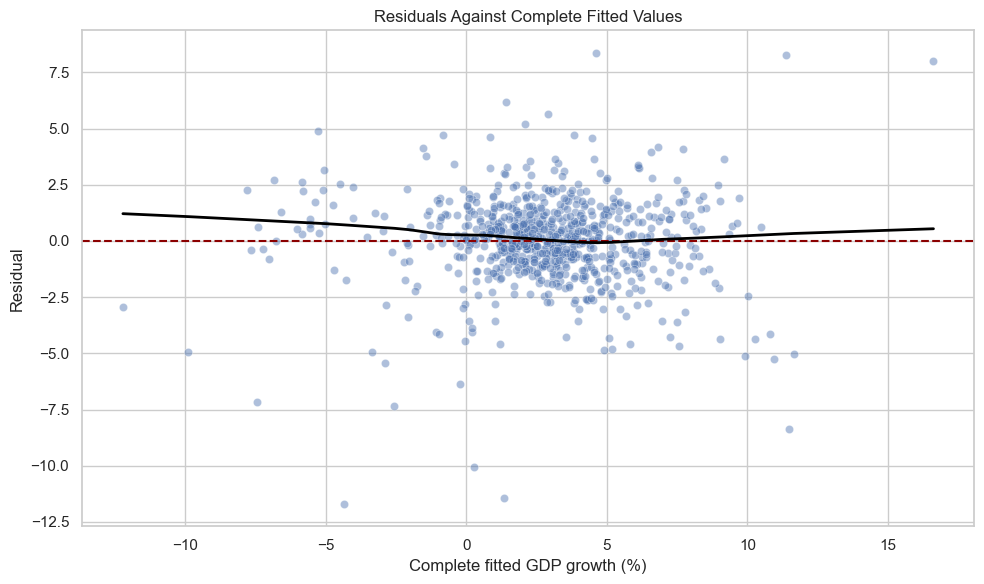

In [164]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=diagnostic_data,
    x="Complete Fitted GDP Growth",
    y="Residual",
    alpha=0.45,
    s=35
)

plt.axhline(
    y=0,
    color="darkred",
    linestyle="--",
    linewidth=1.5
)

sns.regplot(
    data=diagnostic_data,
    x="Complete Fitted GDP Growth",
    y="Residual",
    scatter=False,
    lowess=True,
    line_kws={
        "color": "black",
        "linewidth": 2
    }
)

plt.title("Residuals Against Complete Fitted Values")
plt.xlabel("Complete fitted GDP growth (%)")
plt.ylabel("Residual")

plt.tight_layout()
plt.show()

In [165]:
residual_observations = (
    diagnostic_data
    .reset_index()
    .merge(
        core[
            [
                "Country Code",
                "Country Name",
                "Year",
                "GDP Growth",
                "Productivity Growth",
                "Investment"
            ]
        ],
        on=["Country Code", "Year"],
        how="left"
    )
)

residual_observations["Absolute Residual"] = (
    residual_observations["Residual"].abs()
)

largest_residuals = (
    residual_observations
    .nlargest(15, "Absolute Residual")
    [
        [
            "Country Name",
            "Year",
            "GDP Growth",
            "Productivity Growth",
            "Investment",
            "Complete Fitted GDP Growth",
            "Residual",
            "Absolute Residual"
        ]
    ]
)

display(largest_residuals.round(3))

,Country Name,Year,GDP Growth,Productivity Growth,Investment,Complete Fitted GDP Growth,Residual,Absolute Residual
465,Latvia,2009,-16.0400,0.1200,23.2110,-4.3520,-11.6880,11.6880
774,Ukraine,2014,-10.0790,3.8300,13.3960,1.3530,-11.4320,11.4320
775,Ukraine,2015,-9.7730,0.7500,15.9330,0.2740,-10.0470,10.0470
532,Montenegro,2000,3.1000,14.4600,22.3880,11.4860,-8.3860,8.3860
530,Malta,2017,12.9710,-1.0400,19.1590,4.6050,8.3660,8.3660
513,Malta,2000,19.6810,8.0800,27.3210,11.3920,8.2890,8.2890
376,Ireland,2015,24.6240,20.9300,26.0840,16.6200,8.0040,8.0040
315,Greece,2011,-9.8770,-2.4200,14.0710,-2.5500,-7.3260,7.3260
237,Estonia,2009,-14.6300,-4.7100,21.0090,-7.4550,-7.1750,7.1750
146,Cyprus,2013,-6.5870,-0.6500,12.5650,-0.2380,-6.3500,6.3500


### Assessment of large residuals

The largest errors correspond to economically recognisable events: the Baltic economies during the global financial crisis, Greece and Cyprus during the sovereign-debt crisis, Ukraine in 2014–2015, and Ireland's unusual measured GDP growth in 2015.

These observations are plausible macroeconomic shocks rather than obvious data-entry errors. They remain in the main sample, while the sensitivity check below shows whether they disproportionately influence the coefficients.

In [169]:
serial_correlation_data = (
    residual_observations
    .sort_values(["Country Code", "Year"])
    .copy()
)

serial_correlation_data["Lagged Residual"] = (
    serial_correlation_data
    .groupby("Country Code")["Residual"]
    .shift(1)
)

residual_autocorrelation = (
    serial_correlation_data[
        ["Residual", "Lagged Residual"]
    ]
    .corr()
    .iloc[0, 1]
)

print(
    "First-order residual autocorrelation:",
    round(residual_autocorrelation, 4)
)

First-order residual autocorrelation: 0.4171


### Residual dependence

The first-order residual autocorrelation is approximately **0.42**, indicating
meaningful persistence in unexplained country-specific growth shocks. This is a
descriptive diagnostic rather than a formal test, but it supports inference that
allows errors to be correlated within countries over time.


## 8. Robustness of the standard errors

The model coefficients stay the same when only the covariance estimator changes; what changes is the estimated uncertainty. The table compares conventional, heteroskedasticity-robust, country-clustered, country-and-year-clustered, and Driscoll–Kraay standard errors.

For this undergraduate project, the key point is simple: **the positive conclusions should not depend on only one way of calculating uncertainty**. Country clustering remains the baseline because it directly addresses repeated observations within each country.

In [170]:
# Conventional homoskedastic standard errors
two_way_unadjusted_results = (
    two_way_fe_model.fit(
        cov_type="unadjusted"
    )
)

# Heteroskedasticity-robust standard errors
two_way_robust_results = (
    two_way_fe_model.fit(
        cov_type="robust"
    )
)

# Country-clustered standard errors
two_way_country_clustered_results = (
    two_way_fe_model.fit(
        cov_type="clustered",
        cluster_entity=True
    )
)

# Two-way clustered standard errors
two_way_double_clustered_results = (
    two_way_fe_model.fit(
        cov_type="clustered",
        cluster_entity=True,
        cluster_time=True
    )
)

# Driscoll-Kraay standard errors
two_way_driscoll_kraay_results = (
    two_way_fe_model.fit(
        cov_type="kernel",
        kernel="bartlett",
        bandwidth=3
    )
)

In [171]:
covariance_results = {
    "Unadjusted": two_way_unadjusted_results,
    "Robust": two_way_robust_results,
    "Country clustered": (
        two_way_country_clustered_results
    ),
    "Country and year clustered": (
        two_way_double_clustered_results
    ),
    "Driscoll-Kraay": (
        two_way_driscoll_kraay_results
    )
}

covariance_comparison = pd.concat(
    [
        pd.DataFrame({
            "Estimator": estimator,
            "Variable": result.params.index,
            "Coefficient": result.params.values,
            "Standard Error": result.std_errors.values,
            "t-statistic": result.tstats.values,
            "p-value": result.pvalues.values
        })
        for estimator, result
        in covariance_results.items()
    ],
    ignore_index=True
)

display(covariance_comparison.round(4))

,Estimator,Variable,Coefficient,Standard Error,t-statistic,p-value
0,Unadjusted,Productivity Growth,0.6140,0.0306,20.0368,0.0000
1,Unadjusted,Investment,0.2158,0.0227,9.4869,0.0000
2,Robust,Productivity Growth,0.6140,0.0588,10.4440,0.0000
3,Robust,Investment,0.2158,0.0273,7.8933,0.0000
4,Country clustered,Productivity Growth,0.6140,0.0787,7.8032,0.0000
5,Country clustered,Investment,0.2158,0.0333,6.4799,0.0000
6,Country and year clustered,Productivity Growth,0.6140,0.0781,7.8618,0.0000
7,Country and year clustered,Investment,0.2158,0.0471,4.5779,0.0000
8,Driscoll-Kraay,Productivity Growth,0.6140,0.0482,12.7487,0.0000
9,Driscoll-Kraay,Investment,0.2158,0.0641,3.3684,0.0008


### Robustness result

Productivity growth remains statistically significant at the 1% level under every estimator. Investment also remains significant; its largest standard error occurs under Driscoll–Kraay estimation, but its p-value is still **0.0008**. The main inferential conclusion therefore does not depend on one covariance assumption.

## 9. Sensitivity to the largest residuals

The preferred model is re-estimated after excluding the 15 country–years with the largest absolute residuals. This is a diagnostic rather than a new preferred sample, because the excluded observations are selected using the fitted model itself.

In [166]:
# Identify the country-years with the 15 largest residuals
largest_residual_index = (
    residual_observations
    .nlargest(15, "Absolute Residual")
    [["Country Code", "Year"]]
)

# Mark the observations to exclude
sensitivity_sample = core.merge(
    largest_residual_index.assign(Exclude=True),
    on=["Country Code", "Year"],
    how="left"
)

sensitivity_sample["Exclude"] = (
    sensitivity_sample["Exclude"]
    .fillna(False)
    .astype(bool)
)

sensitivity_sample = (
    sensitivity_sample.loc[
        ~sensitivity_sample["Exclude"]
    ]
    .copy()
)

print("Full-sample observations:", len(core))
print("Sensitivity-sample observations:", len(sensitivity_sample))

Full-sample observations: 779
Sensitivity-sample observations: 764


In [167]:
sensitivity_panel = (
    sensitivity_sample
    .sort_values(["Country Code", "Year"])
    .set_index(["Country Code", "Year"])
)

y_sensitivity = sensitivity_panel["GDP Growth"]

X_sensitivity = sensitivity_panel[
    [
        "Productivity Growth",
        "Investment"
    ]
]

sensitivity_model = PanelOLS(
    dependent=y_sensitivity,
    exog=X_sensitivity,
    entity_effects=True,
    time_effects=True
)

sensitivity_results = sensitivity_model.fit(
    cov_type="clustered",
    cluster_entity=True
)

print(sensitivity_results.summary)

                          PanelOLS Estimation Summary                           
Dep. Variable:             GDP Growth   R-squared:                        0.4703
Estimator:                   PanelOLS   R-squared (Between):              0.3581
No. Observations:                 764   R-squared (Within):               0.5676
Date:                Sun, Aug 09 2026   R-squared (Overall):              0.4554
Time:                        10:03:27   Log-likelihood                   -1432.1
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      312.13
Entities:                          41   P-value                           0.0000
Avg Obs:                       18.634   Distribution:                   F(2,703)
Min Obs:                       17.000                                           
Max Obs:                       19.000   F-statistic (robust):             49.870
                            

In [168]:
residual_sensitivity_comparison = pd.DataFrame({
    "Variable": [
        "Productivity Growth",
        "Investment"
    ],
    "Full-Sample Coefficient": [
        two_way_fe_results.params["Productivity Growth"],
        two_way_fe_results.params["Investment"]
    ],
    "Reduced-Sample Coefficient": [
        sensitivity_results.params["Productivity Growth"],
        sensitivity_results.params["Investment"]
    ],
    "Full-Sample SE": [
        two_way_fe_results.std_errors["Productivity Growth"],
        two_way_fe_results.std_errors["Investment"]
    ],
    "Reduced-Sample SE": [
        sensitivity_results.std_errors["Productivity Growth"],
        sensitivity_results.std_errors["Investment"]
    ],
    "Reduced-Sample p-value": [
        sensitivity_results.pvalues["Productivity Growth"],
        sensitivity_results.pvalues["Investment"]
    ]
})

residual_sensitivity_comparison["Coefficient Change"] = (
    residual_sensitivity_comparison[
        "Reduced-Sample Coefficient"
    ]
    - residual_sensitivity_comparison[
        "Full-Sample Coefficient"
    ]
)

display(residual_sensitivity_comparison.round(4))

,Variable,Full-Sample Coefficient,Reduced-Sample Coefficient,Full-Sample SE,Reduced-Sample SE,Reduced-Sample p-value,Coefficient Change
0,Productivity Growth,0.6140,0.6088,0.0787,0.0696,0.0000,-0.0052
1,Investment,0.2158,0.1690,0.0333,0.0266,0.0000,-0.0468


### Sensitivity result

Removing the 15 largest residuals changes the productivity coefficient only from **0.6140 to 0.6088**. The investment coefficient falls from **0.2158 to 0.1690** but remains positive and statistically significant. Large shocks therefore affect the estimated magnitude of investment more than productivity without reversing the central result.

## 10. Conclusions

The preferred two-way fixed-effects model finds that both productivity growth and investment are positively associated with GDP growth after controlling for persistent country differences and common year shocks.

| Driver | Preferred coefficient | Interpretation |
|---|---:|---|
| Productivity growth | **0.614** | +1 percentage point is associated with about +0.61 percentage points of GDP growth |
| Investment (% of GDP) | **0.216** | +1 percentage point is associated with about +0.22 percentage points of GDP growth |

Productivity is the stronger and more precisely estimated correlate in this sample. Investment also matters, although its magnitude is more sensitive to large country-specific shocks and to how uncertainty is estimated. Both results remain statistically significant across the reported standard-error alternatives.

### Limits of the evidence

- The models estimate contemporaneous **associations**, not causal effects.
- Faster GDP growth may itself raise productivity and investment.
- Time-varying policies, trade conditions, financial conditions, and measurement differences may remain omitted.
- The analysis ends in 2018 because the productivity source does not extend further.
- Education expenditure is descriptive only because its incomplete coverage and likely delayed effects make it unsuitable for the balanced main specification.

### Final answer to the research question

Across 41 European countries in 2000–2018, years with stronger productivity growth and higher investment shares tend to coincide with stronger GDP growth, even after persistent country characteristics and common annual shocks are removed. Productivity shows the clearest and most stable relationship, while investment remains a positive but somewhat more shock-sensitive correlate.